In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

Processing systems: 100%|██████████| 2/2 [00:24<00:00, 12.12s/it]


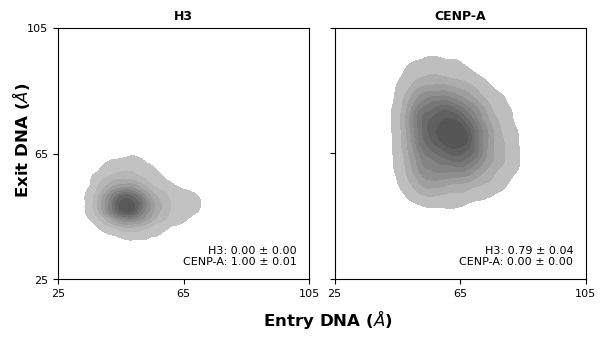

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used here, included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# File pairs: (entry_file, exit_file, title, system_name_for_tsv_lookup)
file_pairs = [
    ("H3-dist-etd_entry.dat",    "H3-dist-etd_exit.dat",    "H3",     "H3"),
    ("cenpa-dist-etd_entry.dat", "cenpa-dist-etd_exit.dat", "CENP-A", "cenpa")
]

# Read KL divergence TSV
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"
kl_df = pd.read_csv(kl_file, sep="\t")

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_name) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    # Load data
    x = np.loadtxt(entry_file)[:, 1][::10]
    y = np.loadtxt(exit_file)[:, 1][::10]

    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    # KDE plot
    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    # Axes formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)
    ax.label_outer()

    # Get KL divergence values for this system
    kl_row = kl_df[kl_df.iloc[:,0] == system_name]
    if not kl_row.empty:
        KL_H3_norm = kl_row.iloc[0, 5]
        KL_H3_std  = kl_row.iloc[0, 6]
        KL_CENPA_norm = kl_row.iloc[0, 7]
        KL_CENPA_std  = kl_row.iloc[0, 8]

        # Format with 2 decimals
        kl_text = (
            f"H3: {KL_H3_norm:.2f} ± {KL_H3_std:.2f}\n"
            f"CENP-A: {KL_CENPA_norm:.2f} ± {KL_CENPA_std:.2f}"
        )

        # Place in bottom-right inside subplot
        ax.text(
            0.95, 0.05, kl_text,
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='bottom',
        )

# Global axis labels
fig.text(0.55, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.55, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.subplots_adjust(
    wspace=0.10,  # horizontal space between subplots
    hspace=0.20,  # vertical space for titles
    top=0.92,
    bottom=0.10,
    left=0.10,
    right=0.98
)

plt.savefig("EtD_CG_WILDTYPE_withKL.pdf")
plt.show()

Processing systems: 100%|██████████| 2/2 [00:25<00:00, 12.63s/it]


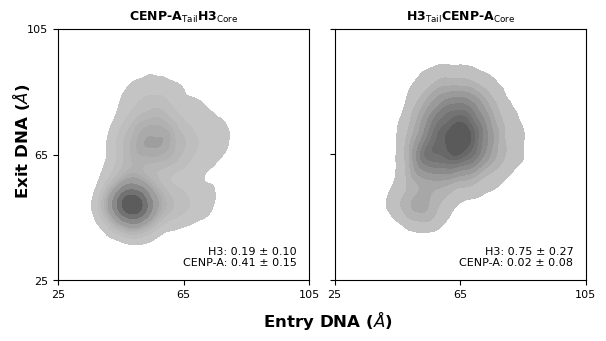

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used here, included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# File pairs: (entry_file, exit_file, title, system_name_for_tsv_lookup)
file_pairs = [
    ("stH3core-dist-etd_entry.dat",    "stH3core-dist-etd_exit.dat",    "CENP-A$_{\\mathrm{Tail}}$H3$_{\\mathrm{Core}}$", "stH3core"),
    ("stcenpacore-dist-etd_entry.dat", "stcenpacore-dist-etd_exit.dat", "H3$_{\\mathrm{Tail}}$CENP-A$_{\\mathrm{Core}}$", "stcenpacore")
]

# Read KL divergence TSV
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"
kl_df = pd.read_csv(kl_file, sep="\t")

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_name) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    # Load data
    x = np.loadtxt(entry_file)[:, 1][::10]
    y = np.loadtxt(exit_file)[:, 1][::10]

    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    # KDE plot
    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    # Axes formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)
    ax.label_outer()

    # Get KL divergence values for this system
    kl_row = kl_df[kl_df.iloc[:,0] == system_name]
    if not kl_row.empty:
        KL_H3_norm = kl_row.iloc[0, 5]
        KL_H3_std  = kl_row.iloc[0, 6]
        KL_CENPA_norm = kl_row.iloc[0, 7]
        KL_CENPA_std  = kl_row.iloc[0, 8]

        # Format with 2 decimals
        kl_text = (
            f"H3: {KL_H3_norm:.2f} ± {KL_H3_std:.2f}\n"
            f"CENP-A: {KL_CENPA_norm:.2f} ± {KL_CENPA_std:.2f}"
        )

        # Place in bottom-right inside subplot
        ax.text(
            0.95, 0.05, kl_text,
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='bottom',
        )

# Global axis labels
fig.text(0.55, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.55, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.subplots_adjust(
    wspace=0.10,  # horizontal space between subplots
    hspace=0.20,  # vertical space for titles
    top=0.92,
    bottom=0.10,
    left=0.10,
    right=0.98
)

plt.savefig("EtD_CG_TAILS_withKL.pdf")
plt.show()

Processing systems: 100%|██████████| 2/2 [00:25<00:00, 12.55s/it]


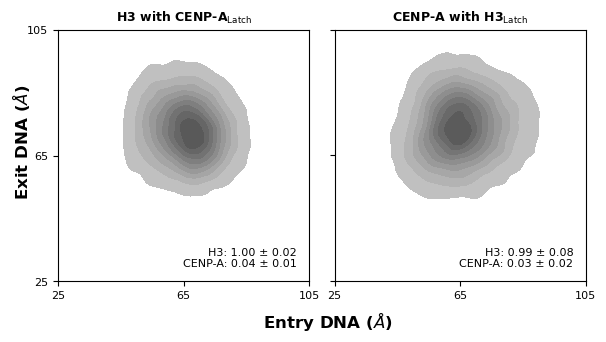

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used here, included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# File pairs: (entry_file, exit_file, title, system_name_for_tsv_lookup)
file_pairs = [
    ("H3withcenpalatch-dist-etd_entry.dat", "H3withcenpalatch-dist-etd_exit.dat",
     "H3 with CENP-A$_{\\mathrm{Latch}}$", "H3withcenpalatch"),
    ("cenpawithH3latch-dist-etd_entry.dat", "cenpawithH3latch-dist-etd_exit.dat",
     "CENP-A with H3$_{\\mathrm{Latch}}$", "cenpawithH3latch")
]

# Read KL divergence TSV
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"
kl_df = pd.read_csv(kl_file, sep="\t")

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_name) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    # Load data
    x = np.loadtxt(entry_file)[:, 1][::10]
    y = np.loadtxt(exit_file)[:, 1][::10]

    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    # KDE plot
    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    # Axes formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)
    ax.label_outer()

    # Get KL divergence values for this system
    kl_row = kl_df[kl_df.iloc[:,0] == system_name]
    if not kl_row.empty:
        KL_H3_norm = kl_row.iloc[0, 5]
        KL_H3_std  = kl_row.iloc[0, 6]
        KL_CENPA_norm = kl_row.iloc[0, 7]
        KL_CENPA_std  = kl_row.iloc[0, 8]

        # Format with 2 decimals
        kl_text = (
            f"H3: {KL_H3_norm:.2f} ± {KL_H3_std:.2f}\n"
            f"CENP-A: {KL_CENPA_norm:.2f} ± {KL_CENPA_std:.2f}"
        )

        # Place in bottom-right inside subplot
        ax.text(
            0.95, 0.05, kl_text,
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='bottom',
        )

# Global axis labels
fig.text(0.55, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.55, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.subplots_adjust(
    wspace=0.10,  # horizontal space between subplots
    hspace=0.20,  # vertical space for titles
    top=0.92,
    bottom=0.10,
    left=0.10,
    right=0.98
)

plt.savefig("EtD_CG_LATCH_withKL.pdf")
plt.show()

Processing systems: 100%|██████████| 2/2 [00:24<00:00, 12.48s/it]


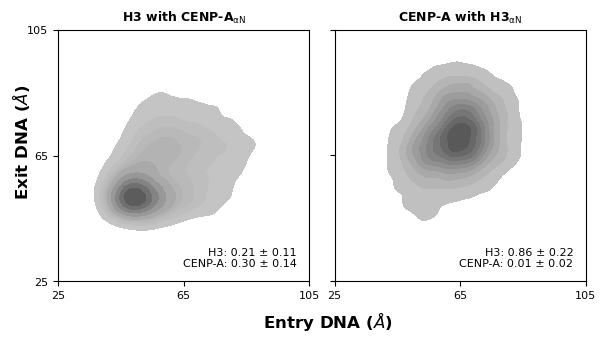

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used here, included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# File pairs: (entry_file, exit_file, title, system_name_for_tsv_lookup)
file_pairs = [
    ("H3withcenpahelix-dist-etd_entry.dat", "H3withcenpahelix-dist-etd_exit.dat",
     "H3 with CENP-A$_{\\mathrm{\u03B1N}}$", "H3withcenpahelix"),
    ("cenpawithH3helix-dist-etd_entry.dat", "cenpawithH3helix-dist-etd_exit.dat",
     "CENP-A with H3$_{\\mathrm{\u03B1N}}$", "cenpawithH3helix")
]

# Read KL divergence TSV
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"
kl_df = pd.read_csv(kl_file, sep="\t")

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_name) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    # Load data
    x = np.loadtxt(entry_file)[:, 1][::10]
    y = np.loadtxt(exit_file)[:, 1][::10]

    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    # KDE plot
    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    # Axes formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)
    ax.label_outer()

    # Get KL divergence values for this system
    kl_row = kl_df[kl_df.iloc[:,0] == system_name]
    if not kl_row.empty:
        KL_H3_norm = kl_row.iloc[0, 5]
        KL_H3_std  = kl_row.iloc[0, 6]
        KL_CENPA_norm = kl_row.iloc[0, 7]
        KL_CENPA_std  = kl_row.iloc[0, 8]

        # Format with 2 decimals
        kl_text = (
            f"H3: {KL_H3_norm:.2f} ± {KL_H3_std:.2f}\n"
            f"CENP-A: {KL_CENPA_norm:.2f} ± {KL_CENPA_std:.2f}"
        )

        # Place in bottom-right inside subplot
        ax.text(
            0.95, 0.05, kl_text,
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='bottom',
        )

# Global axis labels
fig.text(0.55, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.55, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.subplots_adjust(
    wspace=0.10,  # horizontal space between subplots
    hspace=0.20,  # vertical space for titles
    top=0.92,
    bottom=0.10,
    left=0.10,
    right=0.98
)

plt.savefig("EtD_CG_HELIX_withKL.pdf")
plt.show()

Processing systems: 100%|██████████| 2/2 [00:24<00:00, 12.43s/it]


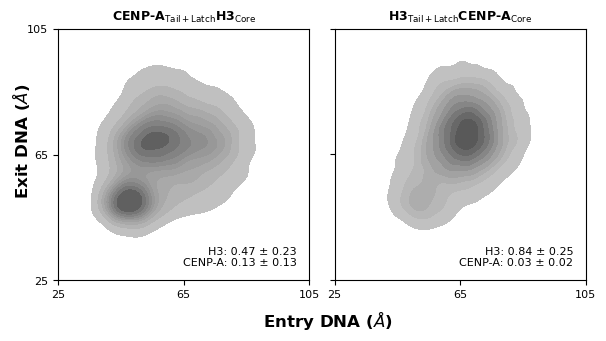

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used here, included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# File pairs: (entry_file, exit_file, title, system_name_for_tsv_lookup)
file_pairs = [
    ("ltH3core-dist-etd_entry.dat",     "ltH3core-dist-etd_exit.dat",
     "CENP-A$_{\\mathrm{Tail+Latch}}$H3$_{\\mathrm{Core}}$", "ltH3core"),
    ("ltcenpacore-dist-etd_entry.dat",  "ltcenpacore-dist-etd_exit.dat",
     "H3$_{\\mathrm{Tail+Latch}}$CENP-A$_{\\mathrm{Core}}$", "ltcenpacore")
]

# Read KL divergence TSV
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"
kl_df = pd.read_csv(kl_file, sep="\t")

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_name) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    # Load data
    x = np.loadtxt(entry_file)[:, 1][::10]
    y = np.loadtxt(exit_file)[:, 1][::10]

    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    # KDE plot
    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    # Axes formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)
    ax.label_outer()

    # Get KL divergence values for this system
    kl_row = kl_df[kl_df.iloc[:,0] == system_name]
    if not kl_row.empty:
        KL_H3_norm = kl_row.iloc[0, 5]
        KL_H3_std  = kl_row.iloc[0, 6]
        KL_CENPA_norm = kl_row.iloc[0, 7]
        KL_CENPA_std  = kl_row.iloc[0, 8]

        # Format with 2 decimals
        kl_text = (
            f"H3: {KL_H3_norm:.2f} ± {KL_H3_std:.2f}\n"
            f"CENP-A: {KL_CENPA_norm:.2f} ± {KL_CENPA_std:.2f}"
        )

        # Place in bottom-right inside subplot
        ax.text(
            0.95, 0.05, kl_text,
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='bottom',
        )

# Global axis labels
fig.text(0.55, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.55, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.subplots_adjust(
    wspace=0.10,  # horizontal space between subplots
    hspace=0.20,  # vertical space for titles
    top=0.92,
    bottom=0.10,
    left=0.10,
    right=0.98
)

plt.savefig("EtD_CG_TAIL+LATCH_withKL.pdf")
plt.show()

Processing systems: 100%|██████████| 2/2 [00:24<00:00, 12.46s/it]


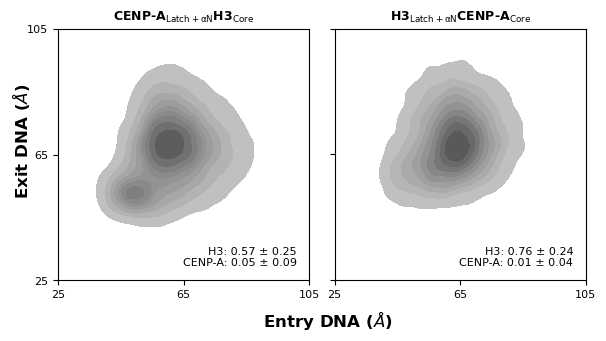

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used here, included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# File pairs: (entry_file, exit_file, title, system_name_for_tsv_lookup)
file_pairs = [
    ("H3withcenpa_latch_helix-dist-etd_entry.dat", "H3withcenpa_latch_helix-dist-etd_exit.dat",
     "CENP-A$_{\\mathrm{Latch+\u03B1N}}$H3$_{\\mathrm{Core}}$", "H3withcenpa_latch_helix"),
    ("cenpawithH3_latch_helix-dist-etd_entry.dat", "cenpawithH3_latch_helix-dist-etd_exit.dat",
     "H3$_{\\mathrm{Latch+\u03B1N}}$CENP-A$_{\\mathrm{Core}}$", "cenpawithH3_latch_helix")
]

# Read KL divergence TSV
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"
kl_df = pd.read_csv(kl_file, sep="\t")

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_name) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    # Load data
    x = np.loadtxt(entry_file)[:, 1][::10]
    y = np.loadtxt(exit_file)[:, 1][::10]

    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    # KDE plot
    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    # Axes formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)
    ax.label_outer()

    # Get KL divergence values for this system
    kl_row = kl_df[kl_df.iloc[:,0] == system_name]
    if not kl_row.empty:
        KL_H3_norm = kl_row.iloc[0, 5]
        KL_H3_std  = kl_row.iloc[0, 6]
        KL_CENPA_norm = kl_row.iloc[0, 7]
        KL_CENPA_std  = kl_row.iloc[0, 8]

        # Format with 2 decimals
        kl_text = (
            f"H3: {KL_H3_norm:.2f} ± {KL_H3_std:.2f}\n"
            f"CENP-A: {KL_CENPA_norm:.2f} ± {KL_CENPA_std:.2f}"
        )

        # Place in bottom-right inside subplot
        ax.text(
            0.95, 0.05, kl_text,
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='bottom',
        )

# Global axis labels
fig.text(0.55, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.55, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.subplots_adjust(
    wspace=0.10,  # horizontal space between subplots
    hspace=0.20,  # vertical space for titles
    top=0.92,
    bottom=0.10,
    left=0.10,
    right=0.98
)

plt.savefig("EtD_CG_LATCH+HELIX_withKL.pdf")
plt.show()

Processing systems: 100%|██████████| 2/2 [00:24<00:00, 12.45s/it]


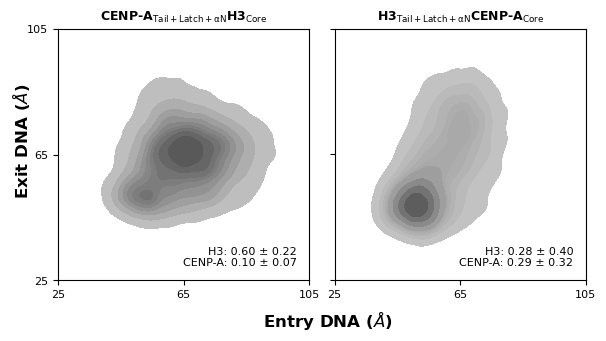

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used here, included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# File pairs: (entry_file, exit_file, title, system_name_for_tsv_lookup)
file_pairs = [
    ("thruhelixH3-dist-etd_entry.dat",     "thruhelixH3-dist-etd_exit.dat",
     "CENP-A$_{\\mathrm{Tail+Latch+\u03B1N}}$H3$_{\\mathrm{Core}}$", "thruhelixH3"),
    ("thruhelixcenpa-dist-etd_entry.dat",  "thruhelixcenpa-dist-etd_exit.dat",
     "H3$_{\\mathrm{Tail+Latch+\u03B1N}}$CENP-A$_{\\mathrm{Core}}$", "thruhelixcenpa")
]

# Read KL divergence TSV
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"
kl_df = pd.read_csv(kl_file, sep="\t")

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_name) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    # Load data
    x = np.loadtxt(entry_file)[:, 1][::10]
    y = np.loadtxt(exit_file)[:, 1][::10]

    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    # KDE plot
    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    # Axes formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)
    ax.label_outer()

    # Get KL divergence values for this system
    kl_row = kl_df[kl_df.iloc[:,0] == system_name]
    if not kl_row.empty:
        KL_H3_norm = kl_row.iloc[0, 5]
        KL_H3_std  = kl_row.iloc[0, 6]
        KL_CENPA_norm = kl_row.iloc[0, 7]
        KL_CENPA_std  = kl_row.iloc[0, 8]

        # Format with 2 decimals
        kl_text = (
            f"H3: {KL_H3_norm:.2f} ± {KL_H3_std:.2f}\n"
            f"CENP-A: {KL_CENPA_norm:.2f} ± {KL_CENPA_std:.2f}"
        )

        # Place in bottom-right inside subplot
        ax.text(
            0.95, 0.05, kl_text,
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='bottom',
        )

# Global axis labels
fig.text(0.55, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.55, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.subplots_adjust(
    wspace=0.10,  # horizontal space between subplots
    hspace=0.20,  # vertical space for titles
    top=0.92,
    bottom=0.10,
    left=0.10,
    right=0.98
)

plt.savefig("EtD_CG_TAIL+LATCH+HELIX_withKL.pdf")
plt.show()

Processing systems: 100%|██████████| 2/2 [00:24<00:00, 12.01s/it]


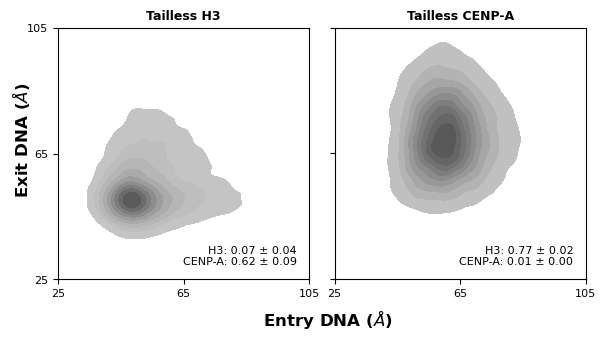

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used here, included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# File pairs: (entry_file, exit_file, title, system_name_for_tsv_lookup)
file_pairs = [
    ("exnotailH3-dist-etd_entry.dat",     "exnotailH3-dist-etd_exit.dat",
     "Tailless H3", "exnotailH3"),
    ("exnotailcenpa-dist-etd_entry.dat",  "exnotailcenpa-dist-etd_exit.dat",
     "Tailless CENP-A", "exnotailcenpa")
]

# Read KL divergence TSV
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"
kl_df = pd.read_csv(kl_file, sep="\t")

# Create 1x2 grid
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_name) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    # Load data
    x = np.loadtxt(entry_file)[:, 1][::10]
    y = np.loadtxt(exit_file)[:, 1][::10]

    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    # KDE plot
    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    # Axes formatting
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)
    ax.label_outer()

    # Get KL divergence values for this system
    kl_row = kl_df[kl_df.iloc[:,0] == system_name]
    if not kl_row.empty:
        KL_H3_norm = kl_row.iloc[0, 5]
        KL_H3_std  = kl_row.iloc[0, 6]
        KL_CENPA_norm = kl_row.iloc[0, 7]
        KL_CENPA_std  = kl_row.iloc[0, 8]

        # Format with 2 decimals
        kl_text = (
            f"H3: {KL_H3_norm:.2f} ± {KL_H3_std:.2f}\n"
            f"CENP-A: {KL_CENPA_norm:.2f} ± {KL_CENPA_std:.2f}"
        )

        # Place in bottom-right inside subplot
        ax.text(
            0.95, 0.05, kl_text,
            transform=ax.transAxes,
            fontsize=8,
            ha='right',
            va='bottom',
        )

# Global axis labels
fig.text(0.55, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.02, 0.55, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')

plt.subplots_adjust(
    wspace=0.10,  # horizontal space between subplots
    hspace=0.20,  # vertical space for titles
    top=0.92,
    bottom=0.10,
    left=0.10,
    right=0.98
)

plt.savefig("EtD_CG_TAILLESS_withKL.pdf")
plt.show()

Processing systems: 100%|██████████| 16/16 [03:19<00:00, 12.45s/it]


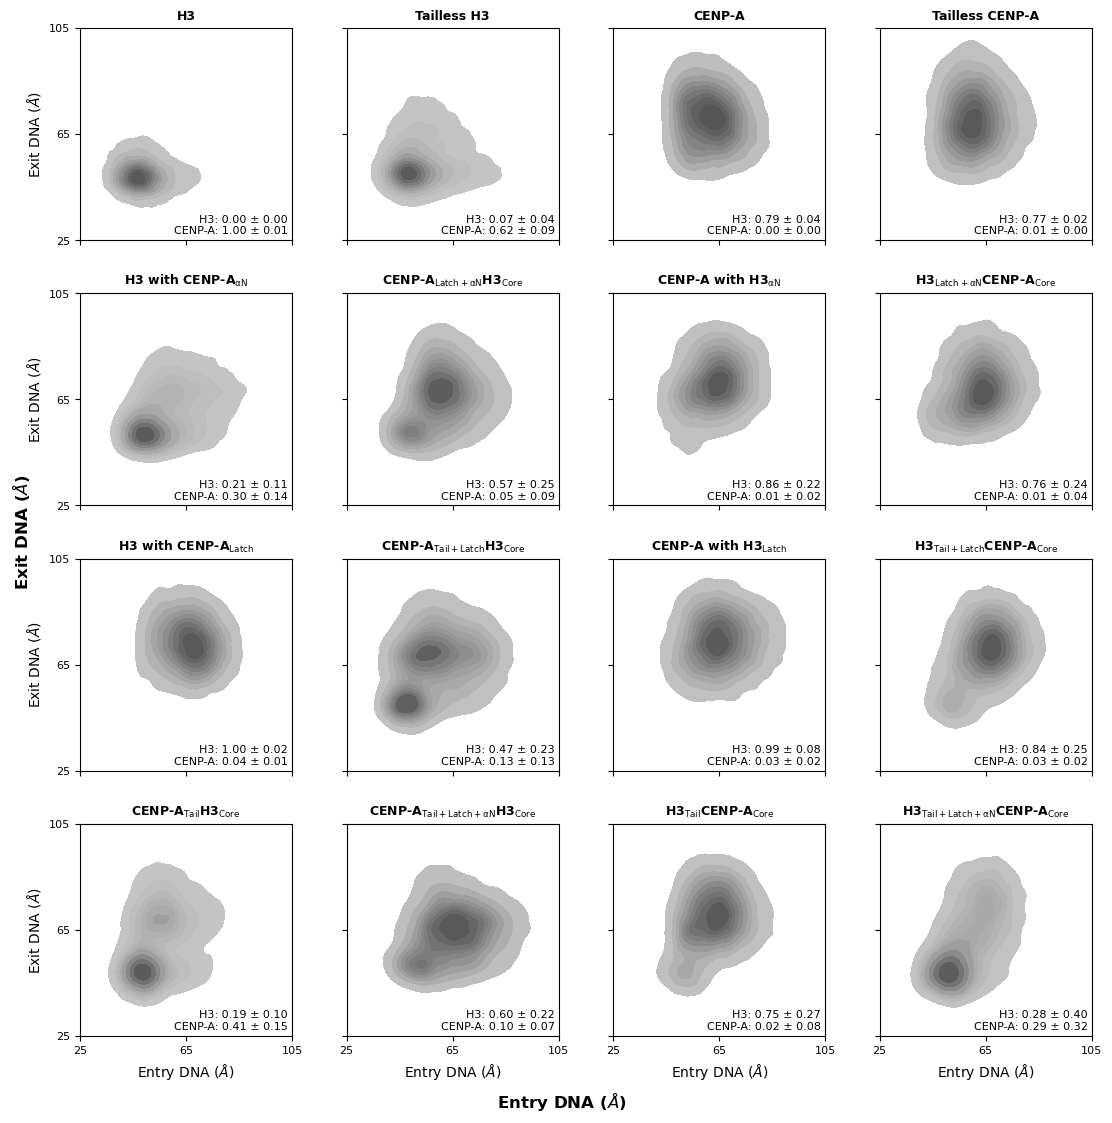

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# Optional function (not used in this version, but included if needed later)
def myplot(x, y, s, bins=1000):
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)
    heatmap = gaussian_filter(heatmap, sigma=s)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return heatmap.T, extent


# -----------------------------
# Load KL divergence data
# -----------------------------
kl_file = "/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD/KL_divergence_with_error.tsv"

kl_df = pd.read_csv(kl_file, sep="\t")
kl_df.columns = kl_df.columns.str.strip()

kl_dict = {}
for _, row in kl_df.iterrows():
    system_name = str(row.iloc[0]).strip()

    kl_dict[system_name] = {
        "H3_norm": float(row.iloc[5]),
        "H3_std": float(row.iloc[6]),
        "CENPA_norm": float(row.iloc[7]),
        "CENPA_std": float(row.iloc[8])
    }


# -----------------------------
# File pairs (NOW WITH SYSTEM KEYS)
# -----------------------------
file_pairs = [

    # ----- Row 1 -----
    ("H3-dist-etd_entry.dat",               "H3-dist-etd_exit.dat",               "H3",                         "H3"),
    ("exnotailH3-dist-etd_entry.dat",       "exnotailH3-dist-etd_exit.dat",       "Tailless H3",                "exnotailH3"),
    ("cenpa-dist-etd_entry.dat",            "cenpa-dist-etd_exit.dat",            "CENP-A",                     "cenpa"),
    ("exnotailcenpa-dist-etd_entry.dat",    "exnotailcenpa-dist-etd_exit.dat",    "Tailless CENP-A",            "exnotailcenpa"),

    # ----- Row 2 -----
    ("H3withcenpahelix-dist-etd_entry.dat",         "H3withcenpahelix-dist-etd_exit.dat",
     "H3 with CENP-A$_{\\mathrm{\u03B1N}}$", "H3withcenpahelix"),
    ("H3withcenpa_latch_helix-dist-etd_entry.dat",  "H3withcenpa_latch_helix-dist-etd_exit.dat",
     "CENP-A$_{\\mathrm{Latch+\u03B1N}}$H3$_{\\mathrm{Core}}$", "H3withcenpa_latch_helix"),
    ("cenpawithH3helix-dist-etd_entry.dat",         "cenpawithH3helix-dist-etd_exit.dat",
     "CENP-A with H3$_{\\mathrm{\u03B1N}}$", "cenpawithH3helix"),
    ("cenpawithH3_latch_helix-dist-etd_entry.dat",  "cenpawithH3_latch_helix-dist-etd_exit.dat",
     "H3$_{\\mathrm{Latch+\u03B1N}}$CENP-A$_{\\mathrm{Core}}$", "cenpawithH3_latch_helix"),

    # ----- Row 3 -----
    ("H3withcenpalatch-dist-etd_entry.dat",   "H3withcenpalatch-dist-etd_exit.dat",
     "H3 with CENP-A$_{\\mathrm{Latch}}$", "H3withcenpalatch"),
    ("ltH3core-dist-etd_entry.dat",           "ltH3core-dist-etd_exit.dat",
     "CENP-A$_{\\mathrm{Tail+Latch}}$H3$_{\\mathrm{Core}}$", "ltH3core"),
    ("cenpawithH3latch-dist-etd_entry.dat",   "cenpawithH3latch-dist-etd_exit.dat",
     "CENP-A with H3$_{\\mathrm{Latch}}$", "cenpawithH3latch"),
    ("ltcenpacore-dist-etd_entry.dat",        "ltcenpacore-dist-etd_exit.dat",
     "H3$_{\\mathrm{Tail+Latch}}$CENP-A$_{\\mathrm{Core}}$", "ltcenpacore"),

    # ----- Row 4 -----
    ("stH3core-dist-etd_entry.dat",        "stH3core-dist-etd_exit.dat",
     "CENP-A$_{\\mathrm{Tail}}$H3$_{\\mathrm{Core}}$", "stH3core"),
    ("thruhelixH3-dist-etd_entry.dat",     "thruhelixH3-dist-etd_exit.dat",
     "CENP-A$_{\\mathrm{Tail+Latch+\u03B1N}}$H3$_{\\mathrm{Core}}$", "thruhelixH3"),
    ("stcenpacore-dist-etd_entry.dat",     "stcenpacore-dist-etd_exit.dat",
     "H3$_{\\mathrm{Tail}}$CENP-A$_{\\mathrm{Core}}$", "stcenpacore"),
    ("thruhelixcenpa-dist-etd_entry.dat",  "thruhelixcenpa-dist-etd_exit.dat",
     "H3$_{\\mathrm{Tail+Latch+\u03B1N}}$CENP-A$_{\\mathrm{Core}}$", "thruhelixcenpa"),
]


# -----------------------------
# Plot setup
# -----------------------------
fig, axes = plt.subplots(4, 4, figsize=(12, 12), sharex=True, sharey=True)

ticks = np.arange(25, 106, 40)

for ax, (entry_file, exit_file, title, system_key) in tqdm(
        zip(axes.flatten(), file_pairs),
        total=len(file_pairs),
        desc="Processing systems"
    ):
    
    x = np.loadtxt(entry_file)[:, 1]
    y = np.loadtxt(exit_file)[:, 1]

    x = x[::10]
    y = y[::10]
    
    df = pd.DataFrame({
        "Entry DNA ($\AA$)": x,
        "Exit DNA ($\AA$)": y
    })

    sns.kdeplot(
        data=df,
        x="Entry DNA ($\AA$)",
        y="Exit DNA ($\AA$)",
        fill=True,
        color='C7',
        ax=ax
    )

    ax.set_xlim(25, 105)
    ax.set_ylim(25, 105)
    ax.set_aspect('equal', adjustable='box')

    ax.set_title(title, fontweight='bold', fontsize=9)

    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.tick_params(axis='both', labelsize=8)

    ax.label_outer()

    # -----------------------------
    # KL annotation
    # -----------------------------
    if system_key in kl_dict:
        vals = kl_dict[system_key]

        text_str = (
            f"H3: {vals['H3_norm']:.2f} ± {vals['H3_std']:.2f}\n"
            f"CENP-A: {vals['CENPA_norm']:.2f} ± {vals['CENPA_std']:.2f}"
        )

        ax.text(
            0.98, 0.02,
            text_str,
            transform=ax.transAxes,
            ha='right',
            va='bottom',
            fontsize=8,  # slightly smaller for 4x4 grid
        )


# -----------------------------
# Global labels
# -----------------------------
fig.text(0.5, 0.02, "Entry DNA ($\AA$)", ha='center', fontsize=12, fontweight='bold')
fig.text(0.04, 0.5, "Exit DNA ($\AA$)", va='center', rotation='vertical', fontsize=12, fontweight='bold')


# -----------------------------
# Layout + save
# -----------------------------
plt.subplots_adjust(
    wspace=0.04,
    hspace=0.25,
    top=0.92,
    bottom=0.08,
    left=0.08,
    right=0.96
)

plt.savefig("EtD_CG_AllSys_105_withKL.pdf")
plt.show()